In [1]:
import sys
import os
# onep is installed via `pip install -e .` -- no sys.path shim needed
import onep as op
import pickle as pkl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import re
from scipy import stats

# set up matplotlib properties
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 7
plt.rcParams['figure.figsize'] = (4.5, 3.5)

In [2]:
# set up directories here
parent_dir = r"C:\Users\ryansenne\Desktop\Dill"
fc_dir = os.path.join(parent_dir, "fc_traces_csv")
A_dir = os.path.join(parent_dir, "cxta_traces_csv")
B_dir = os.path.join(parent_dir, "cxtb_traces_csv")

# list all files that have accepted in and end with .csv
fc_csv_files = [f for f in os.listdir(fc_dir) if f.endswith(".csv") and "accepted" in f]
A_csv_files = [f for f in os.listdir(A_dir) if f.endswith(".csv") and "accepted" in f]
B_csv_files = [f for f in os.listdir(B_dir) if f.endswith(".csv") and "accepted" in f]

# time
time = pd.read_csv(os.path.join(parent_dir, "time.csv")).to_numpy().squeeze()

#output dirs
fc_output_dir = r"\Users\ryansenne\Desktop\dCA1_Figures\Figure_2_Plots\New_Cosine_Heatmaps"
A_output_dir = r"\Users\ryansenne\Desktop\dCA1_Figures\Figure_3_Plots\New_Cosine_Heatmaps"
B_output_dir = r"\Users\ryansenne\Desktop\dCA1_Figures\Figure_3_Plots\New_Cosine_Heatmaps"

FC Cosine Similarity

Processing file: Astro F10
Processing file: Astro F3
Processing file: Astro F5
Processing file: Astro F6
Processing file: Astro F7
Processing file: Astro F8
Processing file: Astro F9
Processing file: Astro M10
Processing file: Astro M3
Processing file: Astro M4
Processing file: Astro M5
Processing file: Astro M6
Processing file: Astro M7
Processing file: Astro M8
Processing file: Astro M9


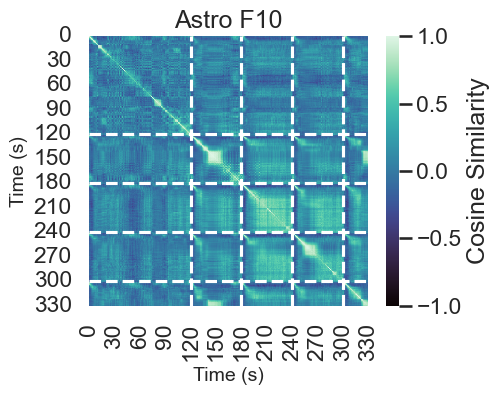

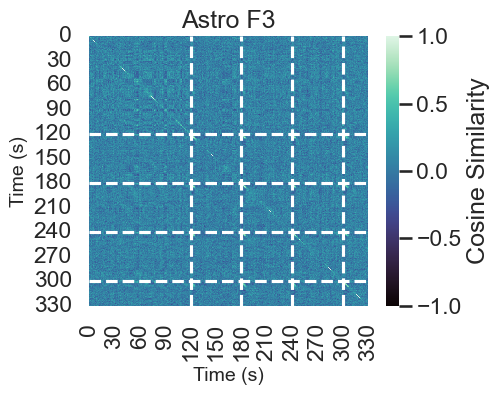

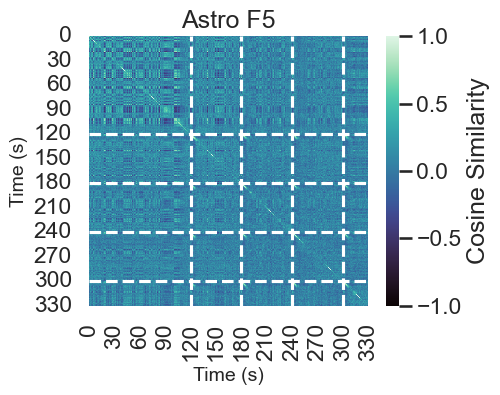

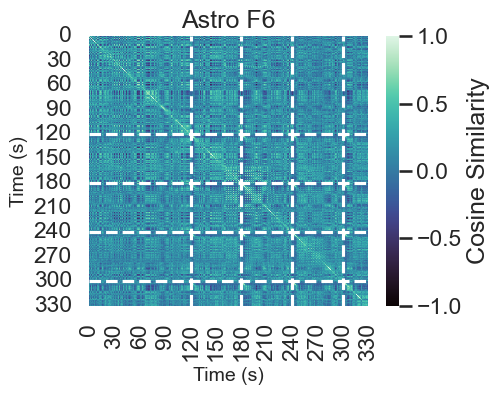

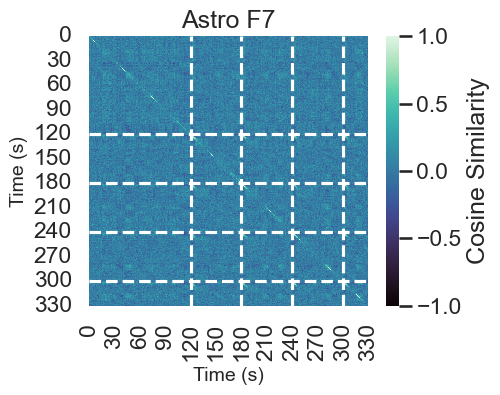

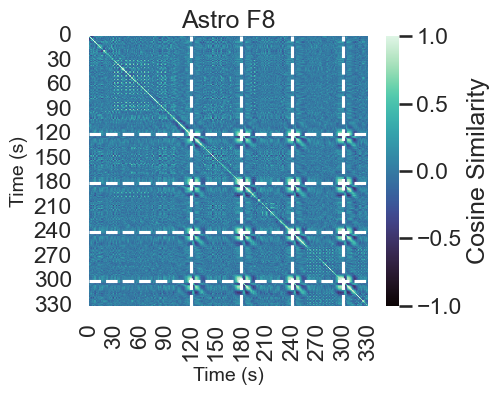

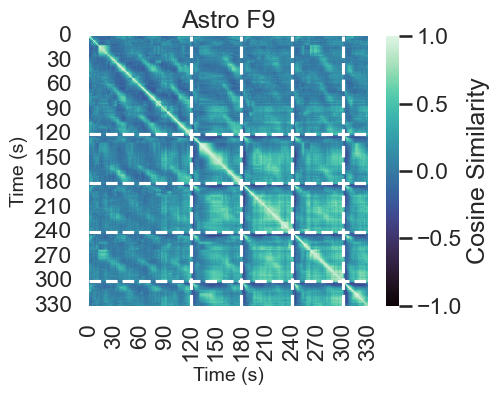

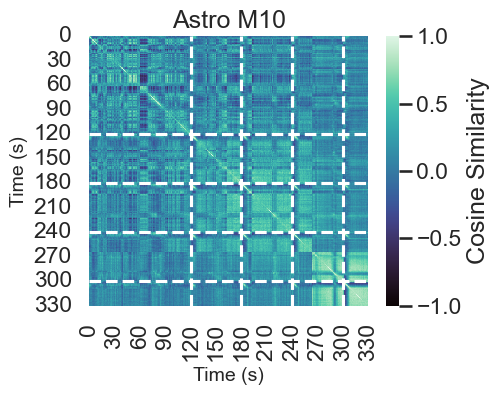

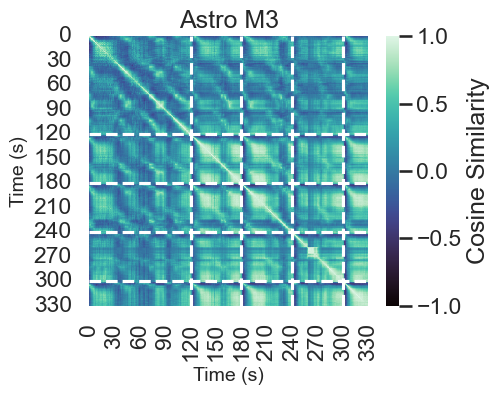

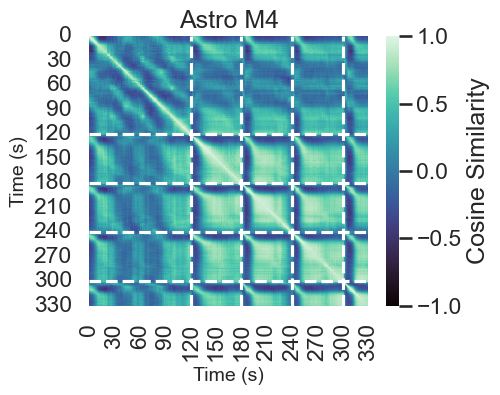

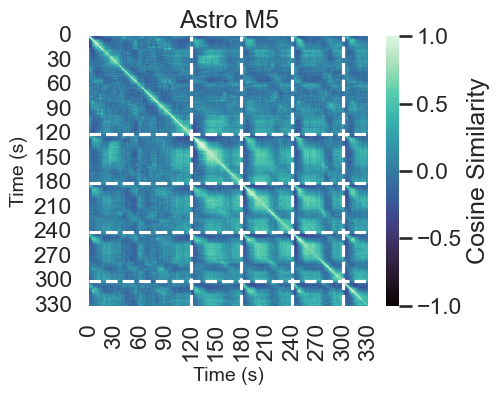

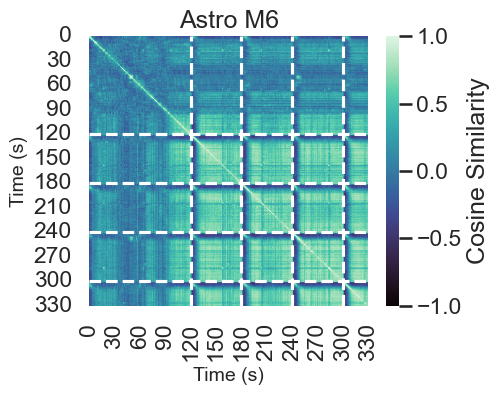

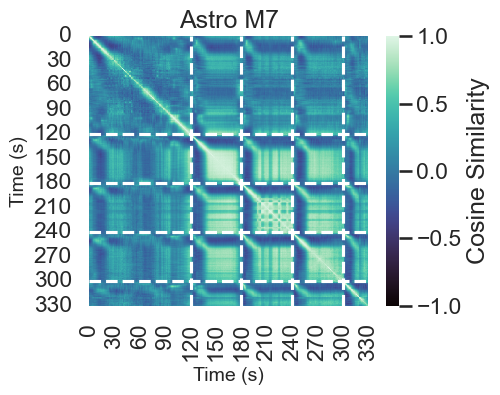

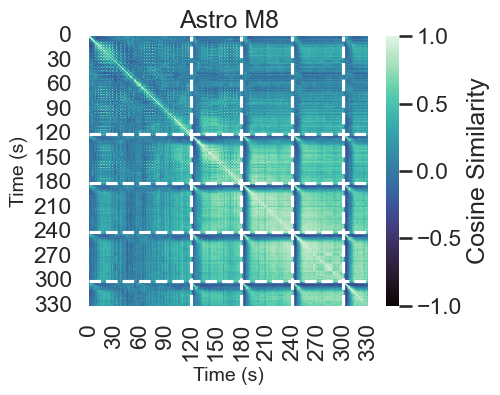

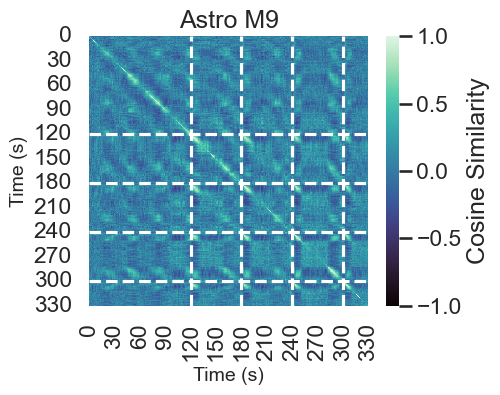

In [ ]:
for csv in fc_csv_files:
    match = re.search(r"astro([MF])(\d+)", csv)
    if match:
        sex = match.group(1)
        subject_id = match.group(2)
        title = f"Astro {sex}{subject_id}"
    print(f"Processing file: {title}")
    df = pd.read_csv(os.path.join(fc_dir, csv))
    data_array = df.to_numpy()[:3602, :] # some files have 3602 time points, others 3603. We always use 3602.
    data_array = stats.zscore(data_array, axis=1)
    # Compute cosine similarity
    arr, fig, ax = op.cosine_similarity_matrix(data_array, time, sns.color_palette("mako", as_cmap=True))
    plt.title(title)
    # ax.savefig(os.path.join(fc_output_dir, f"{title}_Cosine_Similarity_Heatmap_FC.svg"), dpi=600)


Cxt A Cosine Similarity

Processing file: Astro F10
Processing file: Astro F3
Processing file: Astro F5
Processing file: Astro F6
Processing file: Astro F7
Processing file: Astro F8
Processing file: Astro F9
Processing file: Astro M10
Processing file: Astro M3
Processing file: Astro M4
Processing file: Astro M5
Processing file: Astro M9


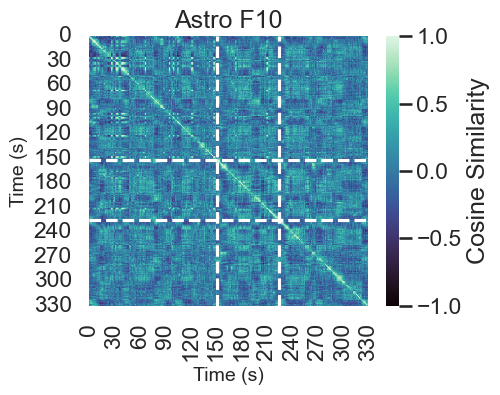

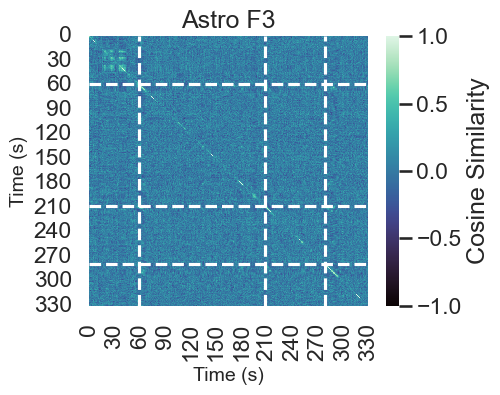

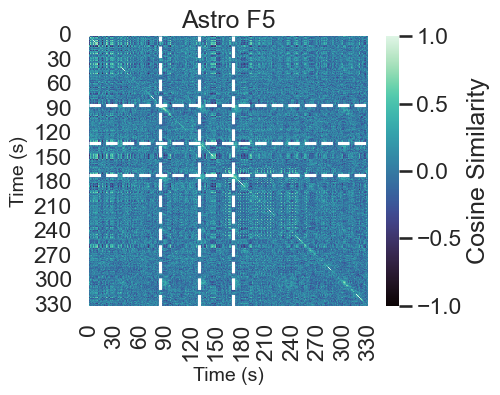

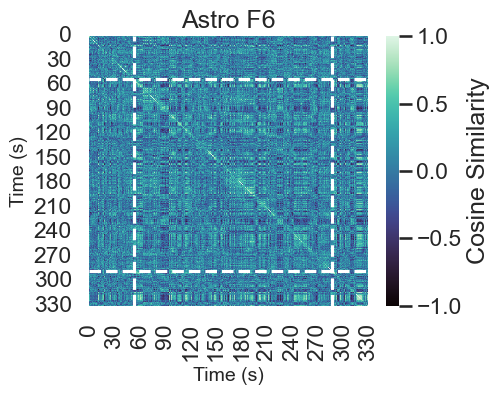

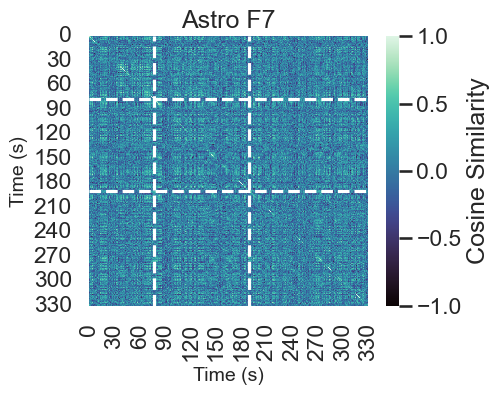

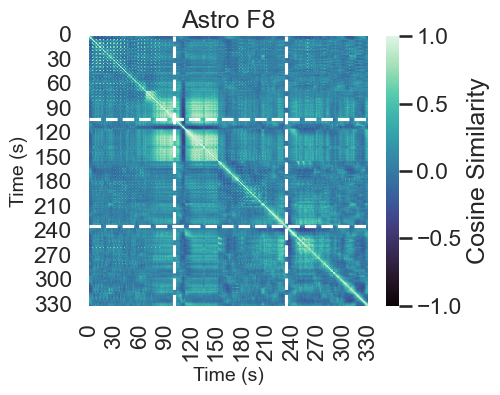

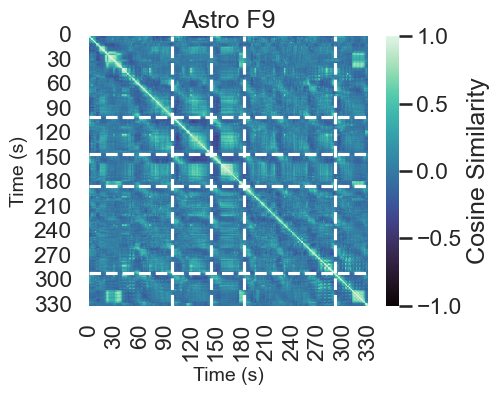

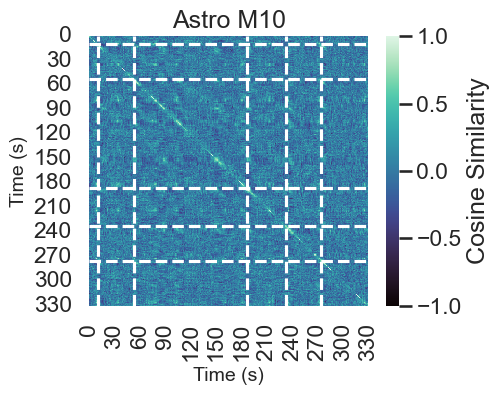

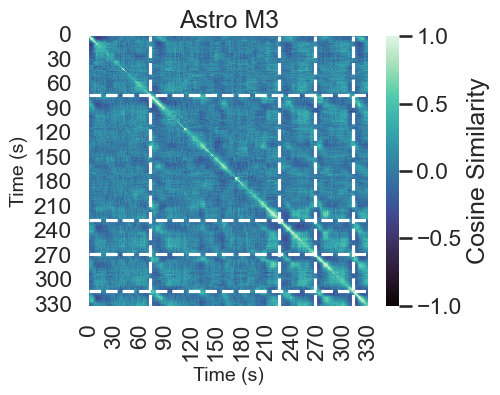

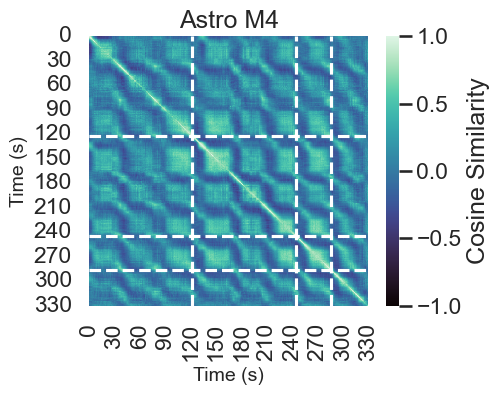

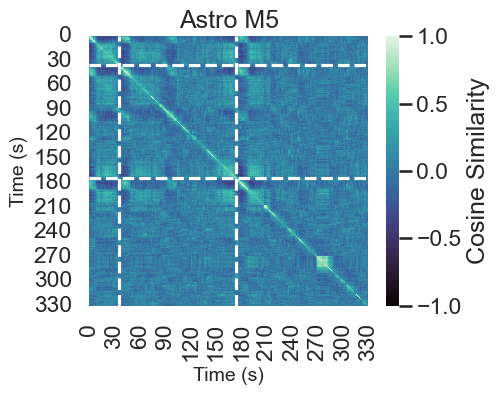

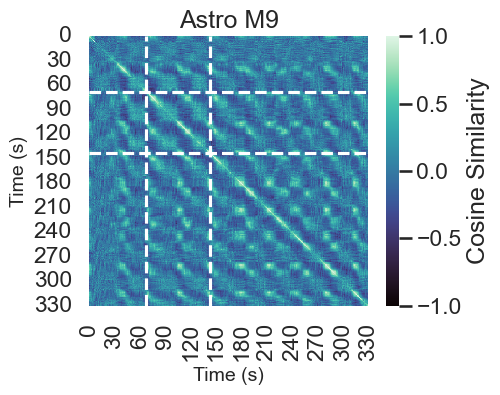

In [ ]:
events_df = r"C:\Users\ryansenne\Desktop\Dill\cxta_traces_csv\event_times_cxta.csv"
events_df = pd.read_csv(events_df)

for csv in A_csv_files:
    match = re.search(r"astro([MF])(\d+)", csv)
    if match:
        sex = match.group(1)
        subject_id = match.group(2)
        title = f"Astro {sex}{subject_id}"
    print(f"Processing file: {title}")
    df = pd.read_csv(os.path.join(A_dir, csv))
    data_array = df.to_numpy()
    t, c = data_array.shape
    if t >= 3602:
        data_array = data_array[:3602, :]
        times = time
    else:
        data_array = data_array[:t, :]
        times = time[:t]
    data_array = stats.zscore(data_array, axis=1)
    # Compute cosine similarity
    events = events_df["astro" + sex + subject_id + "_cxta"].dropna().to_list()
    arr, fig, ax = op.cosine_similarity_matrix(data_array, times, sns.color_palette("mako", as_cmap=True), seq_times=events)
    plt.title(title)
    # ax.savefig(os.path.join(A_output_dir, f"{title}_Cosine_Similarity_Heatmap_CxtA.svg"), dpi=600)


In [4]:
events_df = r"C:\Users\ryansenne\Desktop\Dill\cxta_traces_csv\event_times_cxta.csv"
events_df = pd.read_csv(events_df)

In [9]:
events_df

,astroF10_cxta,astroF3_cxta,astroF5_cxta,astroF6_cxta,astroF7_cxta,astroF8_cxta,astroF9_cxta,astroM10_cxta,astroM3_cxta,astroM4_cxta,astroM5_cxta,astroM9_cxta
0,150.889842,58.761874,84.241952,52.866484,77.047577,100.828983,98.530780,10.000000,72.151405,121.712655,34.880547,67.754843
1,224.532263,207.445622,130.305936,286.783590,189.459685,232.825778,144.394920,52.566718,225.131794,244.116950,174.071717,143.295780
2,NaN,278.490075,169.675154,NaN,NaN,NaN,182.964763,186.262185,266.999059,285.684450,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,290.280856,232.625935,311.764058,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274.792965,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,346.436949,NaN,NaN,NaN,NaN


In [12]:
events_df["astro" + "F" + "3" + "_cxta"].dropna().to_list()

[58.76187436, 207.4456224, 278.4900746]

CxtB Cosine Similarity

Processing file: Astro F10
Processing file: Astro F3
Processing file: Astro F5
Processing file: Astro F6
Processing file: Astro F7
Processing file: Astro F8
Processing file: Astro F9
Processing file: Astro M10
Processing file: Astro M6
Processing file: Astro M7
Processing file: Astro M8


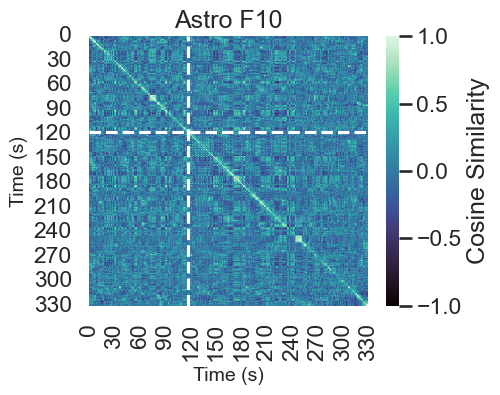

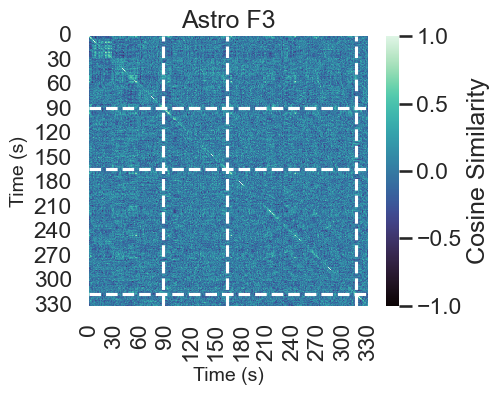

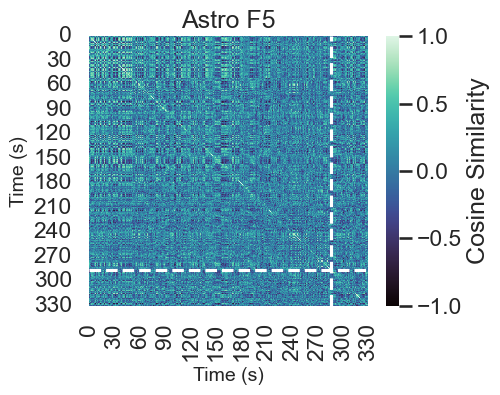

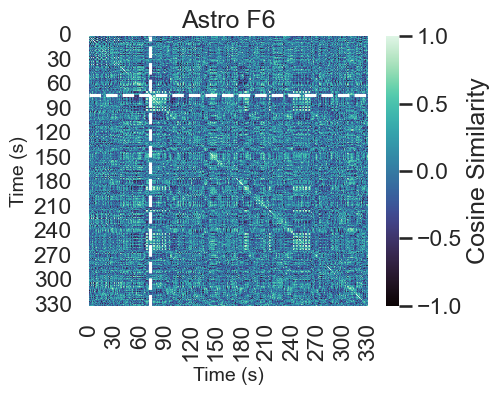

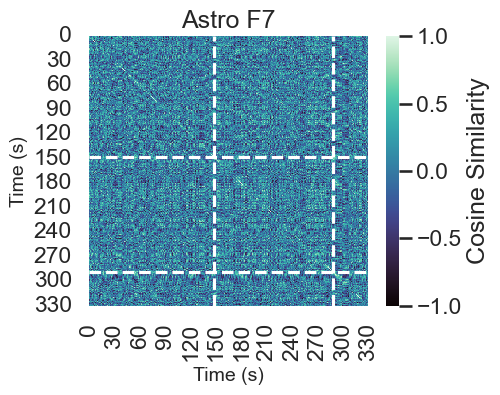

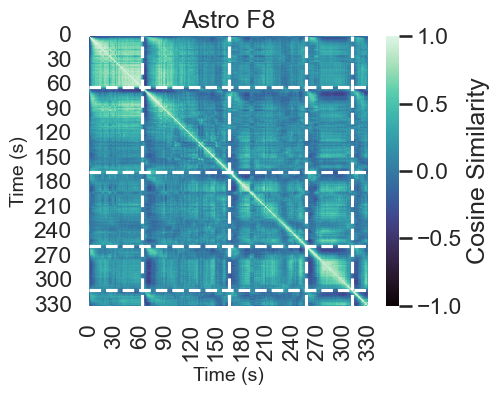

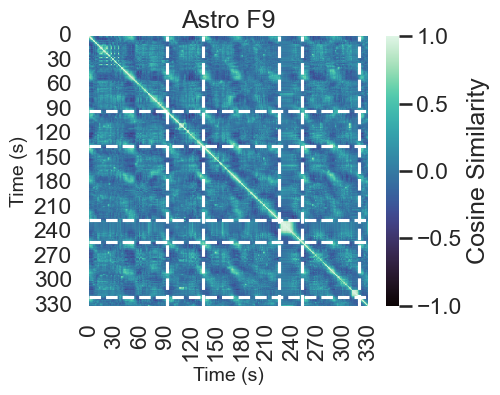

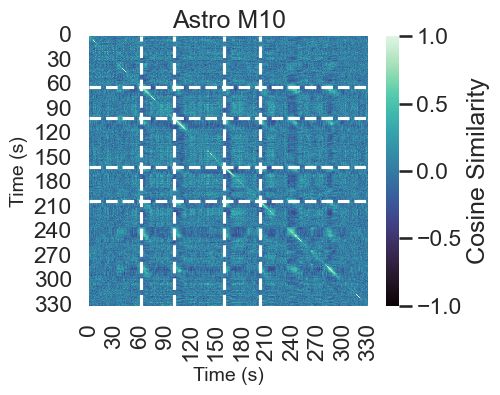

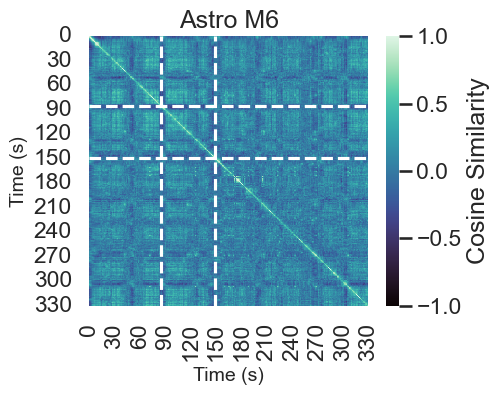

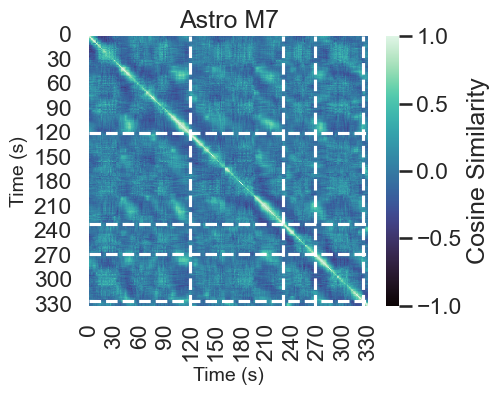

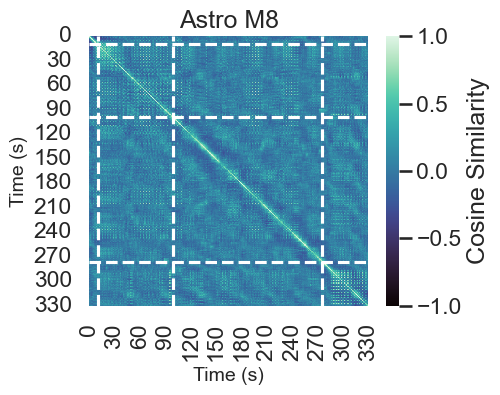

In [16]:
events_df = r"C:\Users\ryansenne\Desktop\Dill\cxtb_traces_csv\event_times_cxtb.csv"
events_df = pd.read_csv(events_df)

for csv in B_csv_files:
    match = re.search(r"astro([MF])(\d+)", csv)
    if match:
        sex = match.group(1)
        subject_id = match.group(2)
        title = f"Astro {sex}{subject_id}"
    print(f"Processing file: {title}")
    df = pd.read_csv(os.path.join(B_dir, csv))
    data_array = df.to_numpy()
    t, c = data_array.shape
    if t >= 3602:
        data_array = data_array[:3602, :]
        times = time
    else:
        data_array = data_array[:t, :]
        times = time[:t]
    data_array = stats.zscore(data_array, axis=1)
    # Compute cosine similarity
    events = events_df["astro" + sex + subject_id + "_cxtb"].dropna().to_list()
    arr, fig, ax = op.cosine_similarity_matrix(data_array, times, sns.color_palette("mako", as_cmap=True), seq_times=events)
    plt.title(title)
    ax.savefig(os.path.join(B_output_dir, f"{title}_Cosine_Similarity_Heatmap_CxtB.svg"), dpi=600)
